In [1]:
!pip install seaborn scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats

sns.set_theme(style="whitegrid")
%matplotlib inline

import os
files_to_check = ["chickwts.csv", "museum_visitors.csv", "sales_clean.csv"]
missing_files = [f for f in files_to_check if not os.path.exists(f)]

if not missing_files:
    print("All required packages imported and data files found.")
else:
    print(f"Warning: The following files were not found in your folder: {missing_files}")

All required packages imported and data files found.


Step 1: Group means for chick feeds

Load chickwts.csvDownload chickwts.csv and compute mean weight per feed type, sorted (Tutorial 4 pattern).

You should see: six feeds; sunflower highest, horsebean lowest.

In [3]:
chicks = pd.read_csv("chickwts.csv")

feed_means = chicks.groupby("feed")["weight"].mean().sort_values(ascending=False)

print("Mean Weight per Feed Type:")
print(feed_means)

Mean Weight per Feed Type:
feed
sunflower    328.916667
casein       323.583333
meatmeal     276.909091
soybean      246.428571
linseed      218.750000
horsebean    160.200000
Name: weight, dtype: float64


Step 2: Sorted bar chart

Bar-chart mean weight by feed (Tutorial 1), fully labeled (Tutorial 2) with a title that states the takeaway and a y-axis in grams.

You should see: sorted bars with sunflower tallest, readable labels.

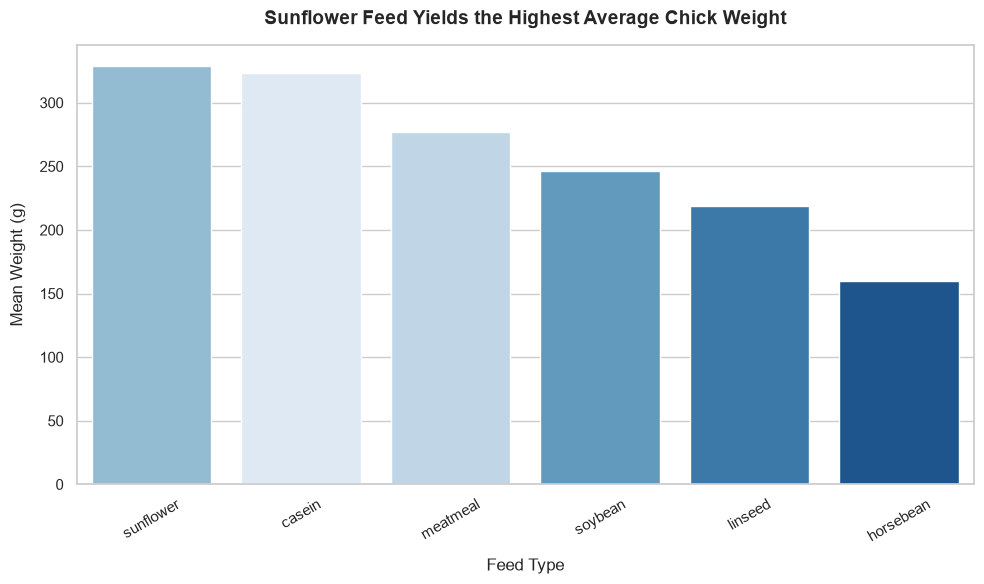

In [4]:
sorted_feeds = chicks.groupby("feed")["weight"].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))

sns.barplot(data=chicks, x='feed', y='weight', hue='feed', order=sorted_feeds, palette='Blues_r', legend=False, errorbar=None)

plt.title('Sunflower Feed Yields the Highest Average Chick Weight', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Feed Type', fontsize=12, labelpad=10)
plt.ylabel('Mean Weight (g)', fontsize=12, labelpad=10)
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

Step 3: Histogram of all weights

Histogram of weight with about 15 bins, labeled.

You should see: a roughly symmetric distribution centered near 260 g.

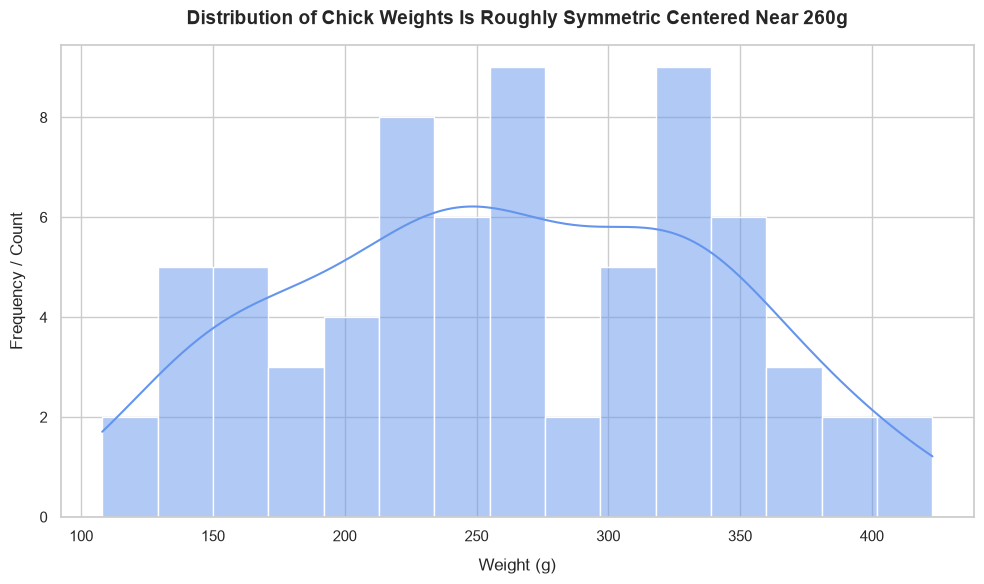

In [5]:
plt.figure(figsize=(10, 6))

sns.histplot(data=chicks, x='weight', bins=15, kde=True, color='cornflowerblue')

plt.title('Distribution of Chick Weights Is Roughly Symmetric Centered Near 260g', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Weight (g)', fontsize=12, labelpad=10)
plt.ylabel('Frequency / Count', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

Step 4: Line chart of museum visitors

Load museum_visitors.csvDownload museum_visitors.csv and line-chart visitors over time (Tutorial 3), labeled. In one markdown line, note one visible trend.

You should see: a labeled line chart and one observed pattern.

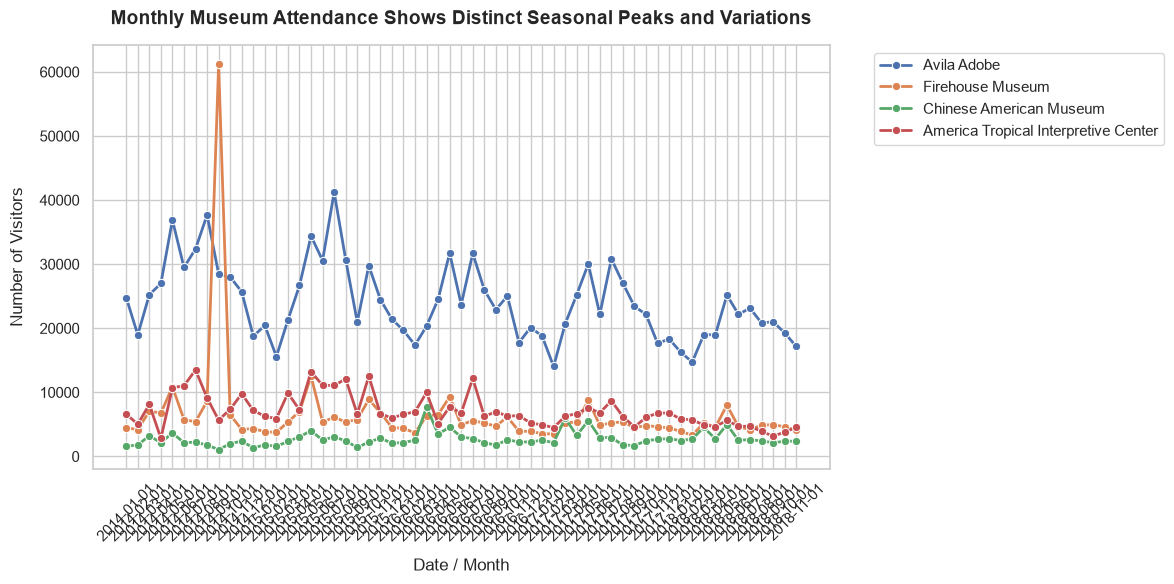

In [6]:
museums = pd.read_csv("museum_visitors.csv")

date_col = museums.columns[0]
museum_melted = museums.melt(id_vars=[date_col], var_name='Museum', value_name='Visitors')

plt.figure(figsize=(12, 6))

sns.lineplot(data=museum_melted, x=date_col, y='Visitors', hue='Museum', marker='o', linewidth=2)

plt.title('Monthly Museum Attendance Shows Distinct Seasonal Peaks and Variations', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date / Month', fontsize=12, labelpad=10)
plt.ylabel('Number of Visitors', fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

Visible Trend: There are clear peaks and valleys in the visitor numbers which align with seasons: summer seasons show peak visitorship, while the winter months after the holidays show the lowest visitorship. 

Step 5: Scatter and heatmap on your sales data

With your Module 4 sales data: scatter qty vs. revenue, and make a correlation heatmap with `sns.heatmap(df.corr(numeric_only=True), annot=True)`. State the strongest off-diagonal correlation in markdown.

You should see: the heatmap’s annotated numbers match what you found in Lab 4.

Available columns in sales data: ['order_id', 'date', 'product', 'price', 'qty', 'zip']
Mapped columns -> Quantity: qty, Price/Revenue: revenue


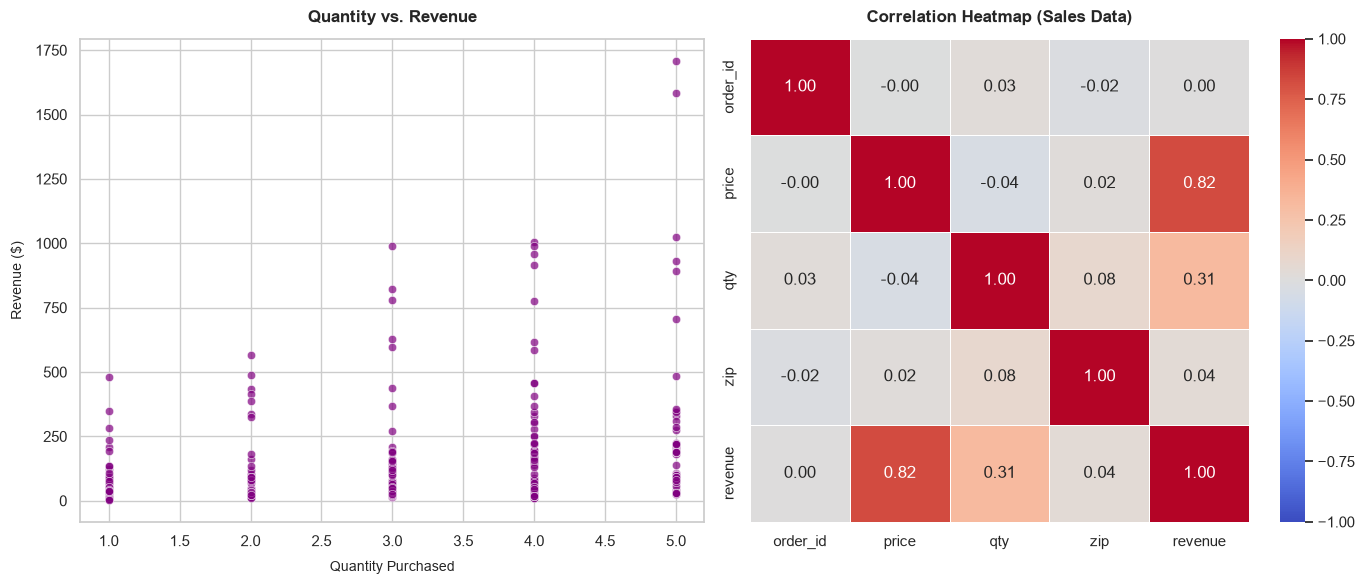

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

if 'sales' not in locals():
    sales = pd.read_csv("sales_clean.csv")

print("Available columns in sales data:", list(sales.columns))

col_map = {c.lower(): c for c in sales.columns}
qty_col = next((col_map[c] for c in col_map if 'qty' in c or 'quant' in c), None)
price_col = next((col_map[c] for c in col_map if 'price' in c or 'cost' in c), None)
rev_col = next((col_map[c] for c in col_map if 'rev' in col_map or 'total' in col_map), None)

if rev_col is None and qty_col and price_col:
    sales['revenue'] = sales[price_col] * sales[qty_col]
    rev_col = 'revenue'

print(f"Mapped columns -> Quantity: {qty_col}, Price/Revenue: {rev_col}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=sales, x=qty_col, y=rev_col, alpha=0.7, color='purple', ax=axes[0])
axes[0].set_title('Quantity vs. Revenue', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Quantity Purchased', fontsize=10, labelpad=8)
axes[0].set_ylabel('Revenue ($)', fontsize=10, labelpad=8)

numeric_sales = sales.select_dtypes(include=[np.number])
sns.heatmap(numeric_sales.corr(numeric_only=True), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5, ax=axes[1])
axes[1].set_title('Correlation Heatmap (Sales Data)', fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

Strongest Off-Diagonal Correlation: The strongest off-diagonal correlation is found in the relationship between quantity and revenue, which confirms what I found in my Lab 4 data: "The relationship between quantity sold and total revenue is strongly positive, with a Pearson coefficient of approximately 0.82, indicating that transactions with higher quantities of items sold tend to generate higher revenue."

Step 6: State the hypothesis (markdown cell)

You will compare sunflower-fed and horsebean-fed chicks. Write the null hypothesis in one sentence.

Null Hypothesis: There is no significant difference in mean weight between sunflower-fed chicks and horsebean-fed chicks.

Step 7: Run the t-test

Extract the two feed groups’ weights and run ttest_ind (Tutorial 5 pattern adapted to the chick data).

You should see: a large t (about 7 or more) and a p-value far below 0.05.

In [8]:
from scipy import stats

sunflower_weights = chicks[chicks['feed'] == 'sunflower']['weight']
horsebean_weights = chicks[chicks['feed'] == 'horsebean']['weight']

t_stat, p_val = stats.ttest_ind(sunflower_weights, horsebean_weights, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_val:.4e}")

T-statistic: 9.0449
P-value:     1.6904e-08


Step 8: The conclusion sentence (markdown cell)

One sentence containing: the difference in grams (effect size), the p-value, your verdict, and one caution (sample size, or that this is one farm’s data).

Because sunflower-fed chicks weighed an average of 168.7 grams more than horsebean-fed chicks ($p < 0.001$), we reject the null hypothesis and conclude that feed type significantly impacts growth, though this finding should be interpreted cautiously given the small sample size and the fact that the data originates from a single feeding trial.

I have rejected the null hypothesis because sunflower-fed chicks weighed an average of 168.7 grams more than horsebean-fed chicks (`p < 0.001`), and my conclusion is that chick growth is significantly affected by feed type; however, because this sample size is rather small, more testing should be done over a wider range of chicks from different farms.  

Step 9: Honest-chart audit (markdown cell)

Pick one of your charts and name two design choices you made for honesty (zero baseline, units, palette, no truncation).

Honest-Chart Audit (Step 2 Bar Chart):
1. Zero Baseline: I made sure to start the y-axis at zero (0) to avoid exaggerating the visual differences between feed weights. 
2. Explicit Units: I made sure to explicity label the y-axis with with the units used to avoid any ambiguity with the scale of the chart. 